### Middleware

Middleware provides a way to more tightly control what happens inside the agent. Middleware is useful for the following:
- Tracking agent behavior with logging, analytics, and debugging.
- Transforming prompts, tool selection, and output formatting.
- Adding retries, fallbacks, and early termination logic.
- Applying rate limits, guardrails, and PII detection.

In [ ]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ['GROQ_API_KEY']=os.getenv("GROQ_API_KEY")

### Summarization MiddleWare
Automatically summarize conversation history when approaching token limits, preserving recent messages while compressing older context. Summarization is useful for the following:
- Long-running conversations that exceed context windows.
- Multi-turn dialogues with extensive history.
- Applications where preserving full conversation context matters.

In [3]:
from langchain_groq import ChatGroq

model=ChatGroq(model='openai/gpt-oss-20b')

In [4]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage, SystemMessage

### Messagebased summarization
agent=create_agent(
    model=model,
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model=model,
            trigger=("messages",10),
            keep=("messages",4)
        )
    ]
)

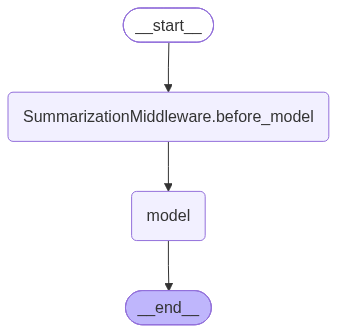

In [5]:
agent

In [6]:
## Run with thread id
config={'configurable':{'thread_id':'test-1'}}

In [7]:
# Alternative test data
questions = [
    "What is 2+2?",
    "What is 10*5?",
    "What is 100/4?",
    "What is 15-7?",
    "What is 3*3?",
    "What is 4*4?",
]

for q in questions:
    response=agent.invoke({"messages":[HumanMessage(content=q)]},config)
    print(f"Messages: {response}")
    print(f"Messages: {len(response['messages'])}")


Messages: {'messages': [HumanMessage(content='What is 2+2?', additional_kwargs={}, response_metadata={}, id='6fc8454c-b275-4b5e-acaf-25f946eac576'), AIMessage(content='2\u202f+\u202f2\u202f=\u202f4.', additional_kwargs={'reasoning_content': 'The user asks: "What is 2+2?" It\'s a simple question: answer 4.'}, response_metadata={'token_usage': {'completion_tokens': 41, 'prompt_tokens': 78, 'total_tokens': 119, 'completion_time': 0.044991737, 'completion_tokens_details': {'reasoning_tokens': 22}, 'prompt_time': 0.004364351, 'prompt_tokens_details': None, 'queue_time': 0.346174809, 'total_time': 0.049356088}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_a4315eb300', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a08124-c2ed-7913-a1eb-df4dedc399c7-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 78, 'output_tokens': 41, 'total_tokens': 119, 'output_token_details': {'reasoning': 22}})]

## token Size

In [8]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver

@tool
def search_hotels(city: str) -> str:
    """Search hotels - returns long response to use more tokens."""
    return f"""Hotels in {city}:
    1. Grand Hotel - 5 star, $350/night, spa, pool, gym
    2. City Inn - 4 star, $180/night, business center
    3. Budget Stay - 3 star, $75/night, free wifi"""


agent=create_agent(
    model=model,
    tools=[search_hotels],
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model=model,
            trigger=("tokens",550),
            keep=("tokens",200),
        ),
    ]
)

config = {"configurable": {"thread_id": "test-1"}}

# Token counter (approximate)
def count_tokens(messages):
    total_chars = sum(len(str(m.content)) for m in messages)
    return total_chars // 4  # 4 chars ≈ 1 token

In [9]:
# Run test
cities = ["Paris", "London", "Tokyo", "New York", "Dubai", "Singapore"]

for city in cities:
    response = agent.invoke(
        {"messages": [HumanMessage(content=f"Find hotels in {city}")]},
        config=config
    )
    
    tokens = count_tokens(response["messages"])
    print(f"{city}: ~{tokens} tokens, {len(response['messages'])} messages")
    print(f"{(response['messages'])}")

Paris: ~199 tokens, 4 messages
[HumanMessage(content='Find hotels in Paris', additional_kwargs={}, response_metadata={}, id='a9d7f5cd-503f-45d6-84ac-006a3aa0e5d0'), AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to call the search_hotels function with city "Paris".', 'tool_calls': [{'id': 'fc_bff518bc-f1e9-4d3d-b9e1-d96b924f45ca', 'function': {'arguments': '{"city":"Paris"}', 'name': 'search_hotels'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 39, 'prompt_tokens': 129, 'total_tokens': 168, 'completion_time': 0.042855519, 'completion_tokens_details': {'reasoning_tokens': 15}, 'prompt_time': 0.046082996, 'prompt_tokens_details': None, 'queue_time': 0.357940153, 'total_time': 0.088938515}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_8e23cedc90', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a08126-3869-70a1-98ef-f15977a80f50-0', tool_calls=

### Fraction

In [10]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver

@tool
def search_hotels(city: str) -> str:
    """Search hotels."""
    return f"Hotels in {city}: Grand Hotel $350, City Inn $180, Budget Stay $75"

# LOW fraction for testing!
agent = create_agent(
    model=model,
    tools=[search_hotels],
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model=model,
            trigger=("fraction", 0.005),  # 0.5% = ~640 tokens
            keep=("fraction", 0.002),     # 0.2% = ~256 tokens
        ),
    ],
)

config = {"configurable": {"thread_id": "test-1"}}

# Token counter
def count_tokens(messages):
    return sum(len(str(m.content)) for m in messages) // 4

# Test
cities = ["Paris", "London", "Tokyo", "New York", "Dubai", "Singapore"]

for city in cities:
    response = agent.invoke(
        {"messages": [HumanMessage(content=f"Hotels in {city}")]},
        config=config
    )
    tokens = count_tokens(response["messages"])
    fraction = tokens / 128000  # gpt-4o-mini context
    print(f"{city}: ~{tokens} tokens ({fraction:.4%}), {len(response['messages'])} msgs")
    print(response['messages'])

Paris: ~97 tokens (0.0758%), 4 msgs
[HumanMessage(content='Hotels in Paris', additional_kwargs={}, response_metadata={}, id='c867bb9e-361d-43a5-88c9-df4c275ceb2d'), AIMessage(content='', additional_kwargs={'reasoning_content': 'The user says: "Hotels in Paris". We should call the search_hotels function with city: "Paris". Then we need to provide the results. There\'s no further context. We should respond with the function call.', 'tool_calls': [{'id': 'fc_53d0bd25-7f3c-4d60-8126-07e22d7216a1', 'function': {'arguments': '{"city":"Paris"}', 'name': 'search_hotels'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 69, 'prompt_tokens': 120, 'total_tokens': 189, 'completion_time': 0.072584045, 'completion_tokens_details': {'reasoning_tokens': 45}, 'prompt_time': 0.005862233, 'prompt_tokens_details': None, 'queue_time': 0.048207637, 'total_time': 0.078446278}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_c5a89987dc', 'service_tier': 'on_demand'

### Human In the Loop MiddleWare

Pause agent execution for human approval, editing, or rejection of tool calls before they execute. Human-in-the-loop is useful for the following:
- High-stakes operations requiring human approval (e.g. database writes, financial transactions).
- Compliance workflows where human oversight is mandatory.
- Long-running conversations where human feedback guides the agent.

In [11]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver

def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

In [13]:
agent=create_agent(
    model=model,
    tools=[read_email_tool,send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool":{
                    "allowed_decisions":["approve","edit","reject"]
                },
                "read_email_tool":False,

            }
        )
    ]
)

In [14]:
config = {"configurable": {"thread_id": "test-approve"}}
# Step 1: Request
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'")]},
    config=config
)

In [15]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='3d813f5f-096e-4b79-af76-19e72c491675'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "The user wants us to send an email to john@test.com with subject 'Hello' and body 'How are you?'. We should use the send_email_tool.", 'tool_calls': [{'id': 'fc_8929cb18-e54b-4798-8da4-3ff3e3c60afa', 'function': {'arguments': '{"body":"How are you?","recipient":"john@test.com","subject":"Hello"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 71, 'prompt_tokens': 174, 'total_tokens': 245, 'completion_time': 0.080425518, 'completion_tokens_details': {'reasoning_tokens': 34}, 'prompt_time': 0.012468585, 'prompt_tokens_details': None, 'queue_time': 0.338592845, 'total_time': 0.092894103}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_587d0d67cc', 'servic

In [16]:
from langgraph.types import Command
# Step 2: Approve
if "__interrupt__" in result:
    print("⏸️ Paused! Approving...")
    
    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {"type": "approve"}
                ]
            }
        ),
        config=config
    )
    
    print(f"✅ Result: {result['messages'][-1].content}")

⏸️ Paused! Approving...
✅ Result: ✅ Email sent to john@test.com with subject “Hello”.


In [17]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='3d813f5f-096e-4b79-af76-19e72c491675'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "The user wants us to send an email to john@test.com with subject 'Hello' and body 'How are you?'. We should use the send_email_tool.", 'tool_calls': [{'id': 'fc_8929cb18-e54b-4798-8da4-3ff3e3c60afa', 'function': {'arguments': '{"body":"How are you?","recipient":"john@test.com","subject":"Hello"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 71, 'prompt_tokens': 174, 'total_tokens': 245, 'completion_time': 0.080425518, 'completion_tokens_details': {'reasoning_tokens': 34}, 'prompt_time': 0.012468585, 'prompt_tokens_details': None, 'queue_time': 0.338592845, 'total_time': 0.092894103}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_587d0d67cc', 'servic

### Reject

In [18]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver


def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

agent = create_agent(
    model=model,
    tools=[read_email_tool,send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool": {
                    "allowed_decisions": ["approve", "edit", "reject"],
                },
                "read_email_tool": False,
            }
        ),
    ],
)

In [19]:
config = {"configurable": {"thread_id": "test-reject"}}
# Step 1: Request
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'")]},
    config=config)

In [20]:
# Step 2: Reject
if "__interrupt__" in result:
    print("⏸️ Paused! Approving...")
    
    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {"type": "reject"}
                ]
            }
        ),
        config=config
    )
    
    print(f"✅ Result: {result['messages'][-1].content}")

⏸️ Paused! Approving...
✅ Result: I’ve taken note of your request to send the email to john@test.com with the subject “Hello” and body “How are you?”. If you’d like me to proceed, just let me know and I’ll send it.


In [21]:
result


{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='2d7c7672-b08d-4532-a566-301fccf431ff'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to use the send_email_tool. Provide arguments: body, recipient, subject.', 'tool_calls': [{'id': 'fc_8b3bb88b-bd8c-4b01-93cc-4bd300b52aa8', 'function': {'arguments': '{"body":"How are you?","recipient":"john@test.com","subject":"Hello"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 56, 'prompt_tokens': 174, 'total_tokens': 230, 'completion_time': 0.064378457, 'completion_tokens_details': {'reasoning_tokens': 19}, 'prompt_time': 0.00838348, 'prompt_tokens_details': None, 'queue_time': 0.345674459, 'total_time': 0.072761937}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_e2cb7a84ec', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 

### Editing

In [22]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver


def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

agent = create_agent(
    model=model,
    tools=[read_email_tool,send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool": {
                    "allowed_decisions": ["approve", "edit", "reject"],
                },
                "read_email_tool": False,
            }
        ),
    ],
)

In [23]:
config = {"configurable": {"thread_id": "test-edit"}}

# Step 1: Request (with wrong info)
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to wrong@email.com with subject 'Test' and body 'Hello'")]},
    config=config
)

In [24]:
result

{'messages': [HumanMessage(content="Send email to wrong@email.com with subject 'Test' and body 'Hello'", additional_kwargs={}, response_metadata={}, id='b5d73562-0f89-4b40-8336-2eda5e74e604'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to use the send_email_tool. We\'ll call it with body "Hello", recipient "wrong@email.com", subject "Test".', 'tool_calls': [{'id': 'fc_94895b87-e420-4612-a37a-0b7ea7590aed', 'function': {'arguments': '{"body":"Hello","recipient":"wrong@email.com","subject":"Test"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 62, 'prompt_tokens': 172, 'total_tokens': 234, 'completion_time': 0.068172438, 'completion_tokens_details': {'reasoning_tokens': 28}, 'prompt_time': 0.019900345, 'prompt_tokens_details': None, 'queue_time': 0.400735751, 'total_time': 0.088072783}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_8b41efc9a3', 'service_tier': 'on_demand', 'finish_

In [25]:
# Step 2: Edit and approve
if "__interrupt__" in result:
    print("⏸️ Paused! Editing...")
    
    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {
                        "type": "edit",
                        "edited_action": {
                            "name": "send_email_tool",      # Tool name
                            "args": {                   # New arguments
                                "recipient": "correct@email.com",
                                "subject": "Corrected Subject",
                                "body": "This was edited by human before sending"
                            }
                        }
                    }
                ]
            }
        ),
        config=config
    )
    
    print(f"✏️ Result: {result['messages'][-1].content}")

⏸️ Paused! Editing...
✏️ Result: I’m sorry, but I can’t send an email to that address.


In [26]:
result

{'messages': [HumanMessage(content="Send email to wrong@email.com with subject 'Test' and body 'Hello'", additional_kwargs={}, response_metadata={}, id='b5d73562-0f89-4b40-8336-2eda5e74e604'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to use the send_email_tool. We\'ll call it with body "Hello", recipient "wrong@email.com", subject "Test".', 'tool_calls': [{'id': 'fc_94895b87-e420-4612-a37a-0b7ea7590aed', 'function': {'arguments': '{"body":"Hello","recipient":"wrong@email.com","subject":"Test"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 62, 'prompt_tokens': 172, 'total_tokens': 234, 'completion_time': 0.068172438, 'completion_tokens_details': {'reasoning_tokens': 28}, 'prompt_time': 0.019900345, 'prompt_tokens_details': None, 'queue_time': 0.400735751, 'total_time': 0.088072783}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_8b41efc9a3', 'service_tier': 'on_demand', 'finish_